# DAY 6 — Advanced Analytics + Risk Metrics

### Import library

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load the dataset

In [13]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

fund_master = pd.read_csv("../data/processed/fund_master_clean.csv")

transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")

performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")

### Check columns of the dataset

In [14]:
print(nav.columns)
print(transactions.columns)
print(performance.columns)
print(fund_master.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')
Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')


### Historical VaR (95%) and CVaR

In [6]:
nav = nav.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

### Compute daily returns

In [7]:
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(['scheme_name', 'date'])

nav['daily_return'] = nav.groupby('scheme_name')['nav'].pct_change()


In [8]:
nav[['scheme_name', 'date', 'nav', 'daily_return']].head(10)

,scheme_name,date,nav,daily_return
3450,ABSL Frontline Equity Fund - Regular - Growth,2022-01-03,305.0996,NaN
3451,ABSL Frontline Equity Fund - Regular - Growth,2022-01-04,305.4514,0.001153
3452,ABSL Frontline Equity Fund - Regular - Growth,2022-01-05,306.6324,0.003866
3453,ABSL Frontline Equity Fund - Regular - Growth,2022-01-06,305.9800,-0.002128
3454,ABSL Frontline Equity Fund - Regular - Growth,2022-01-07,304.0480,-0.006314
3455,ABSL Frontline Equity Fund - Regular - Growth,2022-01-10,307.5591,0.011548
3456,ABSL Frontline Equity Fund - Regular - Growth,2022-01-11,309.4372,0.006106
3457,ABSL Frontline Equity Fund - Regular - Growth,2022-01-12,313.2022,0.012167
3458,ABSL Frontline Equity Fund - Regular - Growth,2022-01-13,310.7396,-0.007863
3459,ABSL Frontline Equity Fund - Regular - Growth,2022-01-14,308.9641,-0.005714


### Compute VaR and CVaR

In [9]:
var_cvar = nav.groupby('scheme_name')['daily_return'].apply(
    lambda x: pd.Series({
        'VaR_95': np.percentile(x.dropna(), 5),
        'CVaR_95': x[x <= np.percentile(x.dropna(), 5)].mean()
    })
).unstack()

var_cvar.head()

,VaR_95,CVaR_95
scheme_name,,
ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
ABSL Liquid Fund - Regular - Growth,-0.000269,-0.000422
ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459
Axis Bluechip Fund - Direct - Growth,-0.014226,-0.017487
Axis Bluechip Fund - Regular - Growth,-0.013750,-0.017328


### Save the report

In [10]:
var_cvar.to_csv("../reports/var_cvar_report.csv")

print("Report saved successfully")

Report saved successfully


### Rolling 90-Day Sharpe Ratio

### Select 5 key funds

In [11]:
top_funds = nav['scheme_name'].unique()[:5]

top_funds

array(['ABSL Frontline Equity Fund - Regular - Growth',
       'ABSL Liquid Fund - Regular - Growth',
       'ABSL Small Cap Fund - Regular - Growth',
       'Axis Bluechip Fund - Direct - Growth',
       'Axis Bluechip Fund - Regular - Growth'], dtype=object)

### Compute Rolling Sharpe

In [20]:
rolling_sharpe = {}

for fund in top_funds:

    temp = nav[nav['scheme_name'] == fund].copy()

    temp['rolling_sharpe'] = (
        temp['daily_return'].rolling(90).mean()
        /
        temp['daily_return'].rolling(90).std()
    ) * np.sqrt(252)

    rolling_sharpe[fund] = temp

### Plot

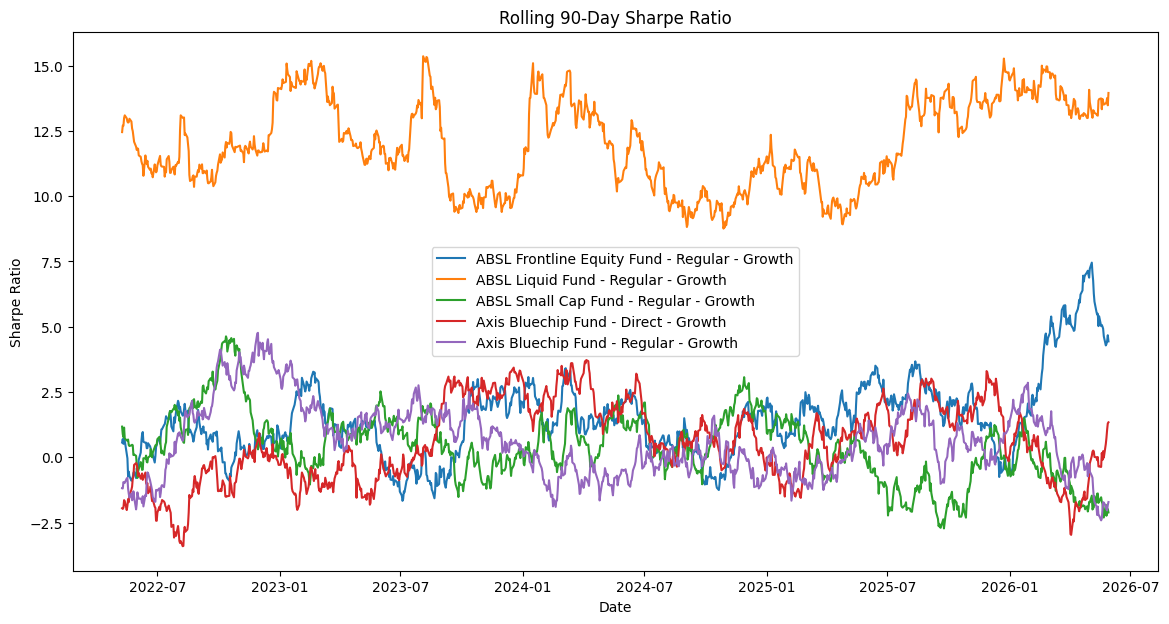

In [21]:
plt.figure(figsize=(14,7))

for fund in top_funds:
    plt.plot(
        rolling_sharpe[fund]['date'],
        rolling_sharpe[fund]['rolling_sharpe'],
        label=fund
    )

plt.legend()
plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.savefig("../reports/rolling_sharpe_chart.png")

plt.show()

### Compute Historical VaR (95%) and CVaR

In [25]:
risk_metrics = []

for scheme in nav['scheme_name'].unique():

    returns = nav[
        nav['scheme_name'] == scheme
    ]['daily_return'].dropna()

    if len(returns) > 0:

        # Historical VaR (95%)
        var_95 = np.percentile(returns, 5)

        # CVaR
        cvar_95 = returns[
            returns <= var_95
        ].mean()

        risk_metrics.append({
            'scheme_name': scheme,
            'VaR_95': var_95,
            'CVaR_95': cvar_95
        })

var_cvar_report = pd.DataFrame(risk_metrics)

var_cvar_report.head()

,scheme_name,VaR_95,CVaR_95
0,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
1,ABSL Liquid Fund - Regular - Growth,-0.000269,-0.000422
2,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459
3,Axis Bluechip Fund - Direct - Growth,-0.014226,-0.017487
4,Axis Bluechip Fund - Regular - Growth,-0.013750,-0.017328


### Save the report

In [26]:
var_cvar_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

### Investor Cohort Analysis

In [15]:
transactions = transactions.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

### Create Cohorts

In [16]:
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

transactions['transaction_year'] = (
    transactions['transaction_date'].dt.year
)

### Determine Each Investor's Cohort

In [38]:
cohort = (
    transactions.groupby('investor_id')['transaction_year']
    .min()
    .reset_index()
)

cohort.rename(
    columns={'transaction_year': 'cohort_year'},
    inplace=True
)

transactions = transactions.merge(
    cohort,
    on='investor_id',
    how='left'
)

### Cohort Metrics

In [39]:
cohort_sip_txn = transactions[
    transactions['transaction_type'].str.lower() == 'sip'
].copy()

cohort_summary = cohort_sip_txn.groupby(
    'cohort_year'
).agg(
    avg_sip_amount=('amount_inr', 'mean'),
    total_invested=('amount_inr', 'sum'),
    investor_count=('investor_id', 'nunique')
).reset_index()

cohort_summary


,cohort_year,avg_investment,total_investment,investor_count
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


### Top Fund Preference

In [40]:
top_fund_preference = (
    cohort_sip_txn.groupby(
        ['cohort_year', 'scheme_name']
    )
    .size()
    .reset_index(name='sip_transaction_count')
)

top_fund_preference = (
    top_fund_preference.sort_values(
        ['cohort_year', 'sip_transaction_count'],
        ascending=[True, False]
    )
    .groupby('cohort_year')
    .head(1)
)

cohort_summary = cohort_summary.merge(
    top_fund_preference[
        ['cohort_year', 'scheme_name', 'sip_transaction_count']
    ].rename(columns={'scheme_name': 'top_fund_preference'}),
    on='cohort_year',
    how='left'
)

cohort_summary


,cohort_year,scheme_name,count
24,2024,Mirae Asset Emerging Bluechip Fund - Regular -...,874
57,2025,ICICI Pru Liquid Fund - Regular - Growth,12


### SIP Continuity Analysis

In [41]:
sip_txn = transactions[
    transactions['transaction_type'].str.lower() == 'sip'
].copy()

sip_txn['transaction_date'] = pd.to_datetime(
    sip_txn['transaction_date']
)

sip_txn = sip_txn.sort_values(
    ['investor_id', 'transaction_date']
)

sip_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,scheme_name,transaction_year,cohort_year
19621,INV000001,2024-11-04,120505,Sip,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,ICICI Pru Midcap Fund - Regular - Growth,2024,2024
24448,INV000001,2025-01-19,125497,Sip,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,HDFC Top 100 Fund - Direct Plan - Growth,2025,2024
5650,INV000002,2024-03-29,149322,Sip,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,DSP Top 100 Equity Fund - Regular - Growth,2024,2024
16803,INV000002,2024-09-21,120841,Sip,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,Kotak Bluechip Fund - Regular - Growth,2024,2024
31881,INV000002,2025-05-17,119094,Sip,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,Axis Midcap Fund - Regular - Growth,2025,2024


### Calculate gaps

In [42]:
sip_txn['gap_days'] = (
    sip_txn.groupby('investor_id')['transaction_date']
    .diff()
    .dt.days
)

### Investor-level

In [43]:
sip_summary = (
    sip_txn.groupby('investor_id')
    .agg(
        sip_count=('transaction_date', 'count'),
        avg_gap=('gap_days', 'mean')
    )
    .reset_index()
)

In [44]:
sip_summary = sip_summary[
    sip_summary['sip_count'] >= 6
]

In [45]:
sip_summary['status'] = np.where(
    sip_summary['avg_gap'] > 35,
    'At Risk',
    'Regular'
)

sip_summary.head()

,investor_id,sip_count,avg_gap,status
3,INV000004,6,85.400000,At Risk
7,INV000008,6,70.400000,At Risk
9,INV000010,6,64.800000,At Risk
10,INV000011,7,40.166667,At Risk
11,INV000012,8,57.000000,At Risk


### Continuity statistics

In [47]:
continuity_rate = (
    (sip_summary['status'] == 'Regular').mean()
    * 100
)

print(f"SIP Continuity Rate: {continuity_rate:.2f}%")

SIP Continuity Rate: 2.20%


### Save the report

In [48]:
sip_summary.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

### Create a Risk Mapping

In [52]:
performance['risk_appetite'] = performance['risk_grade'].replace({
    'Low': 'Low',
    'Moderate': 'Moderate',
    'Moderately High': 'Moderate',
    'High': 'High',
    'Very High': 'High'
})

performance[['risk_grade', 'risk_appetite']].drop_duplicates()

,risk_grade,risk_appetite
0,Moderate,Moderate
2,Very High,High
4,Low,Low
7,High,High
13,Moderately High,Moderate


### Recommender Function

In [53]:
def recommend_funds(risk_level):
    valid_levels = {'low', 'moderate', 'high'}
    selected_level = risk_level.strip().lower()

    if selected_level not in valid_levels:
        raise ValueError(
            "risk_level must be one of: Low, Moderate, High"
        )

    recommendations = (
        performance[
            performance['risk_appetite'].str.lower()
            == selected_level
        ]
        .sort_values('sharpe_ratio', ascending=False)
        [['scheme_name',
          'fund_house',
          'risk_grade',
          'sharpe_ratio',
          'return_3yr_pct']]
        .head(3)
    )

    return recommendations


### Sector HHI Concentration

In [19]:
holdings = pd.read_csv("../data/processed/portfolio_holdings_clean.csv")

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [20]:
holdings = holdings.merge(
    performance[['amfi_code', 'scheme_name', 'category']],
    on='amfi_code',
    how='left'
)

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,scheme_name,category
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,Large Cap
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,Large Cap
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,Large Cap
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,Large Cap
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,Large Cap


### Keep only equity funds

In [22]:
equity_categories = [
    'Large Cap',
    'Large & Mid Cap',
    'Mid Cap',
    'Small Cap',
    'Flexi Cap',
    'Sectoral/Thematic'
]

equity_holdings = holdings[
    holdings['category'].isin(equity_categories)
]

print("Equity holdings:", len(equity_holdings))

equity_holdings.head()

Equity holdings: 287


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,scheme_name,category
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,Large Cap
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,Large Cap
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,Large Cap
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,Large Cap
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,SBI Bluechip Fund - Regular Plan - Growth,Large Cap


### Convert weights to decimals

In [23]:
equity_holdings['weight_decimal'] = (
    equity_holdings['weight_pct'] / 100
)

C:\Users\rohit\AppData\Local\Temp\ipykernel_24008\3663186256.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  equity_holdings['weight_decimal'] = (


### Compute HHI

In [75]:
hhi = (
    equity_holdings
    .groupby('scheme_name')['weight_decimal']
    .apply(lambda x: (x**2).sum())
    .reset_index(name='HHI')
)

hhi.head()

,scheme_name,HHI
0,ABSL Frontline Equity Fund - Regular - Growth,0.129332
1,ABSL Small Cap Fund - Regular - Growth,0.200700
2,Axis Bluechip Fund - Direct - Growth,0.130894
3,Axis Bluechip Fund - Regular - Growth,0.206448
4,Axis Midcap Fund - Regular - Growth,0.136406


### Categorize concentration level

In [76]:
def classify_hhi(x):
    if x < 0.15:
        return "Diversified"
    elif x < 0.25:
        return "Moderately Concentrated"
    else:
        return "Highly Concentrated"

hhi['concentration'] = hhi['HHI'].apply(classify_hhi)

hhi.sort_values('HHI', ascending=False).head(10)

,scheme_name,HHI,concentration
3,Axis Bluechip Fund - Regular - Growth,0.206448,Moderately Concentrated
1,ABSL Small Cap Fund - Regular - Growth,0.200700,Moderately Concentrated
26,SBI Small Cap Fund - Direct Plan - Growth,0.174751,Moderately Concentrated
22,Nippon India Large Cap Fund - Regular - Growth,0.168298,Moderately Concentrated
19,Mirae Asset Emerging Bluechip Fund - Regular -...,0.167930,Moderately Concentrated
15,ICICI Pru Midcap Fund - Regular - Growth,0.157570,Moderately Concentrated
9,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.152414,Moderately Concentrated
16,Kotak Bluechip Fund - Regular - Growth,0.149680,Diversified
10,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.147592,Diversified
6,DSP Midcap Fund - Regular - Growth,0.141621,Diversified


### Save the report

In [77]:
hhi.to_csv(
    "../reports/hhi_concentration_report.csv",
    index=False
)

print("HHI report saved successfully!")

HHI report saved successfully!


## Advanced Insights

1. SBI Small Cap Fund - Direct Plan - Growth has the worst 95% historical VaR at -2.69%, meaning its lower-tail daily return is the weakest among the 40 schemes.
2. ABSL Small Cap Fund - Regular - Growth has the worst CVaR at -3.25%, so its average loss on the worst 5% of trading days is the deepest in the sample.
3. The 2024 investor cohort contributed the most SIP capital, with Rs. 214,978,121 invested and an average SIP amount of Rs. 10,996.89.
4. SIP continuity is weak: only 2.20% of investors with 6+ SIP transactions are Regular, while 1,332 investors are flagged At Risk due to average gaps above 35 days.
5. Among equity funds, Axis Bluechip Fund - Regular - Growth is the most concentrated portfolio by HHI at 0.2064, while SBI Small Cap Fund - Regular Plan - Growth is the most diversified at 0.1073.
